In [ ]:
import warnings
import matplotlib

# 1. Suppress all general Python warnings (like Deprecation or Performance)
warnings.filterwarnings('ignore')

# 2. Specifically suppress Matplotlib font warnings which are common in multilingual plots
matplotlib.logging.getLogger('matplotlib.font_manager').setLevel(matplotlib.logging.ERROR)

# 3. Optional: Set Pandas display options for a cleaner look
import pandas as pd
pd.options.mode.chained_assignment = None  # Silent SettingWithCopyWarning

--- DATASET INSIGHTS ---
Total Records: 400
Unique Questions: 102
Total Evaluators: 9
-------------------------


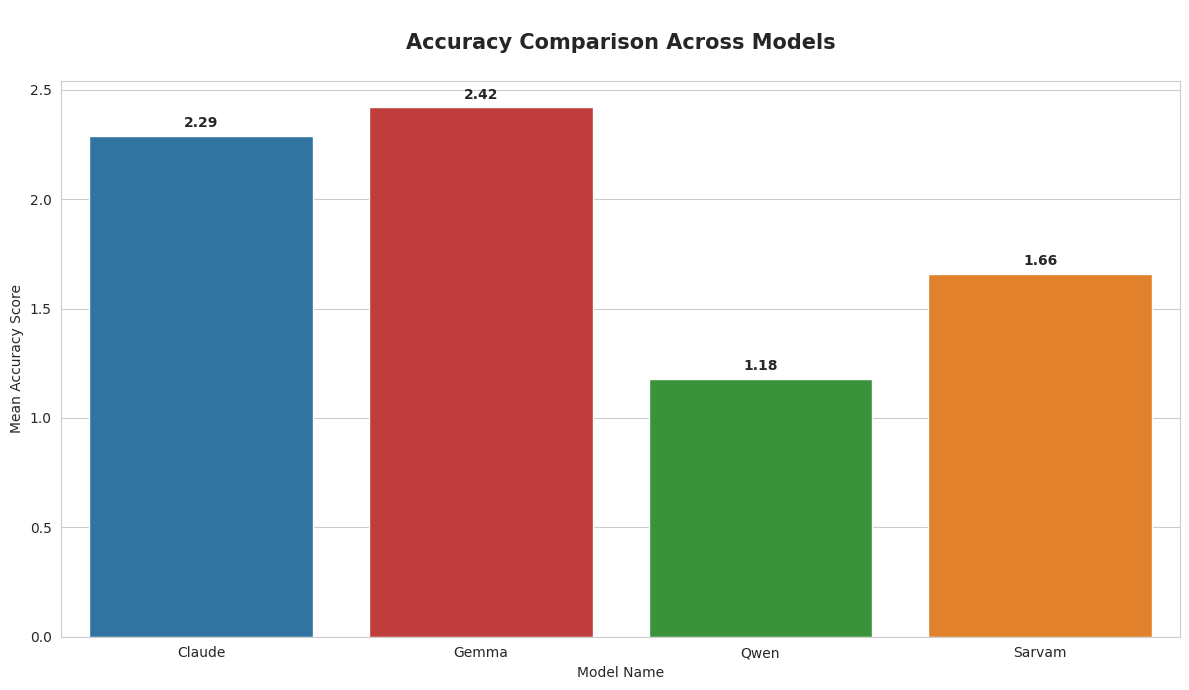

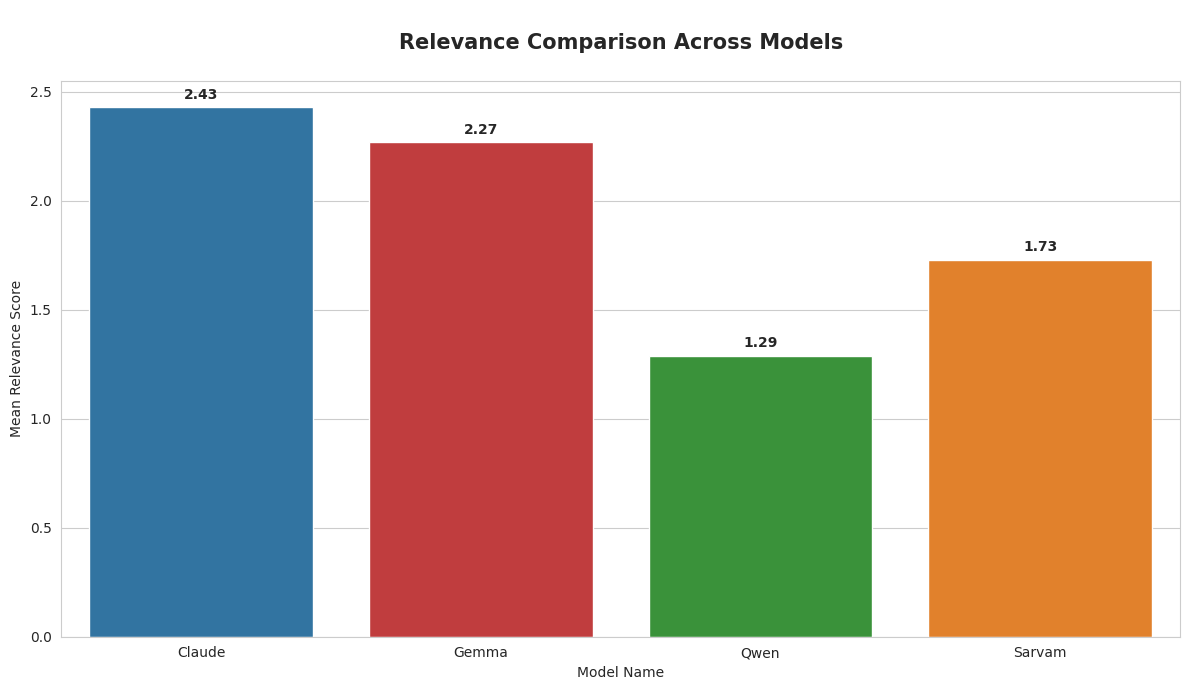

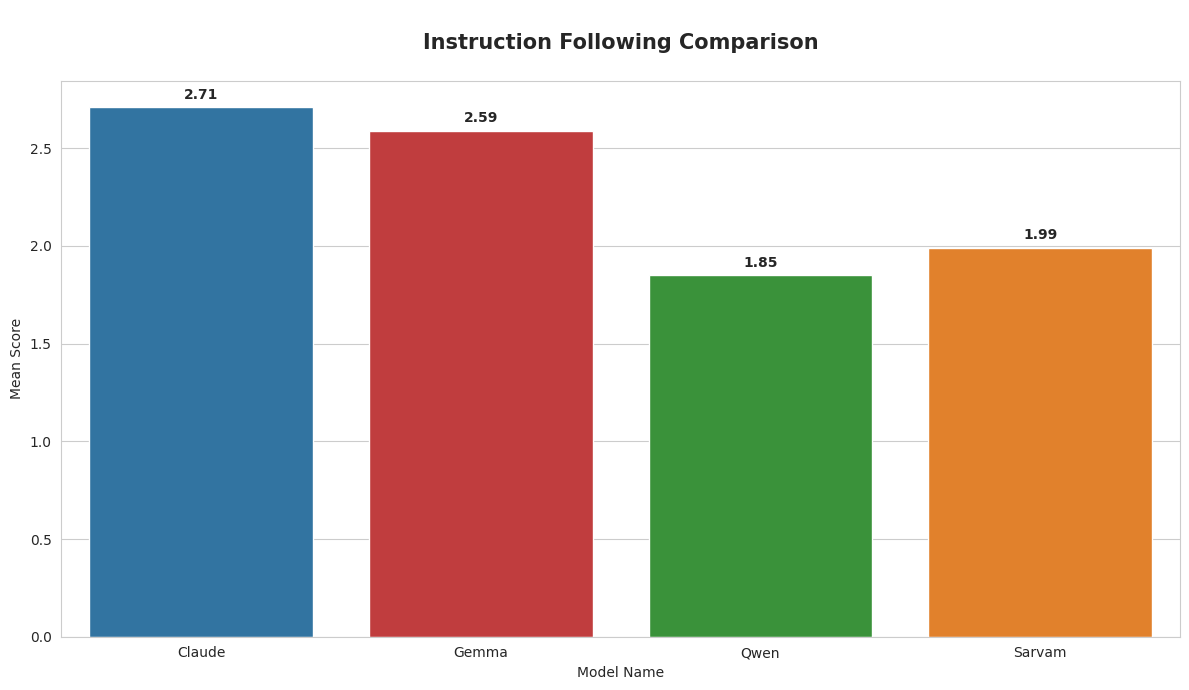

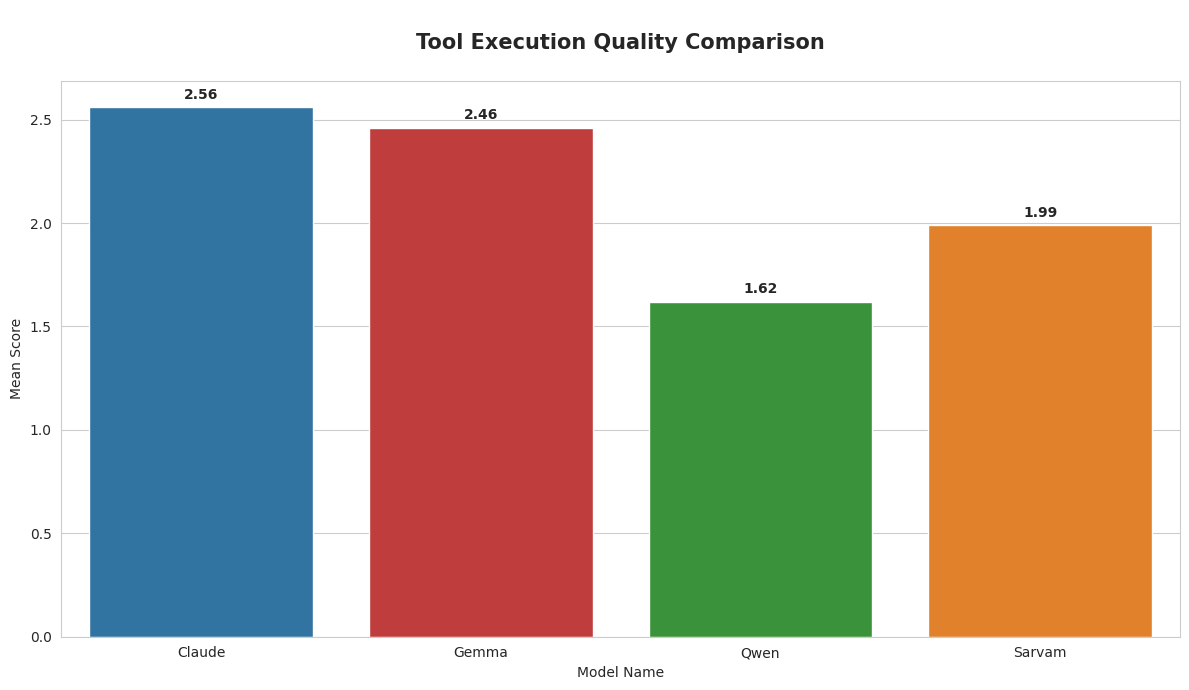

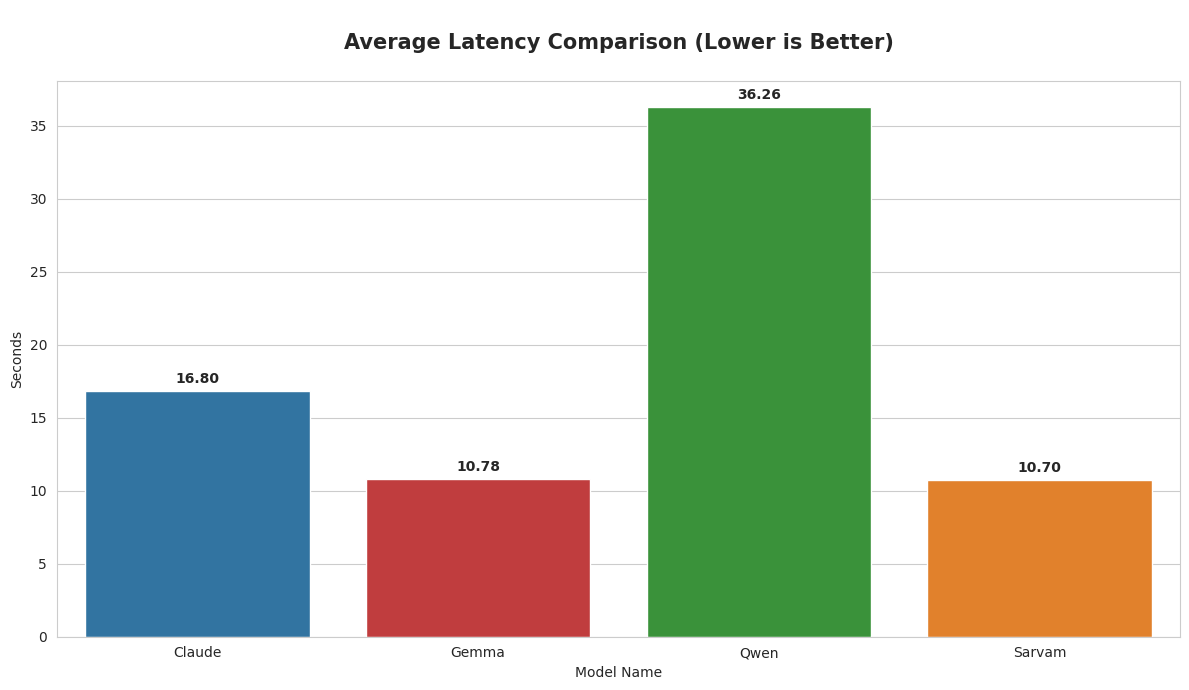

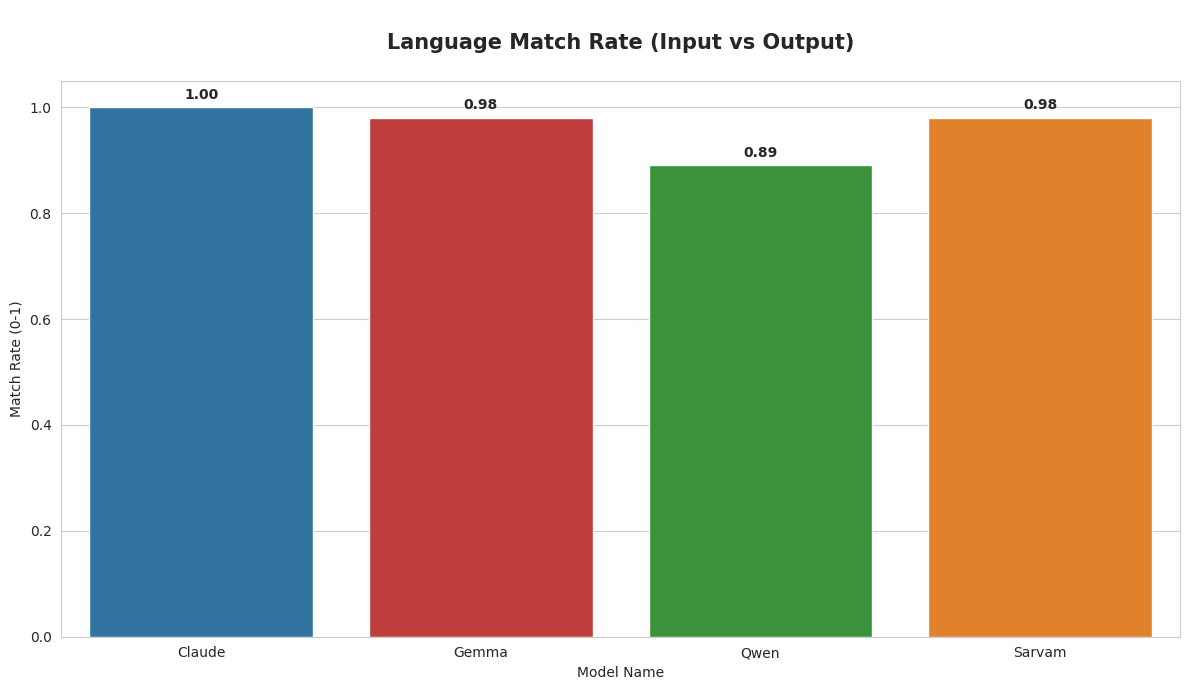

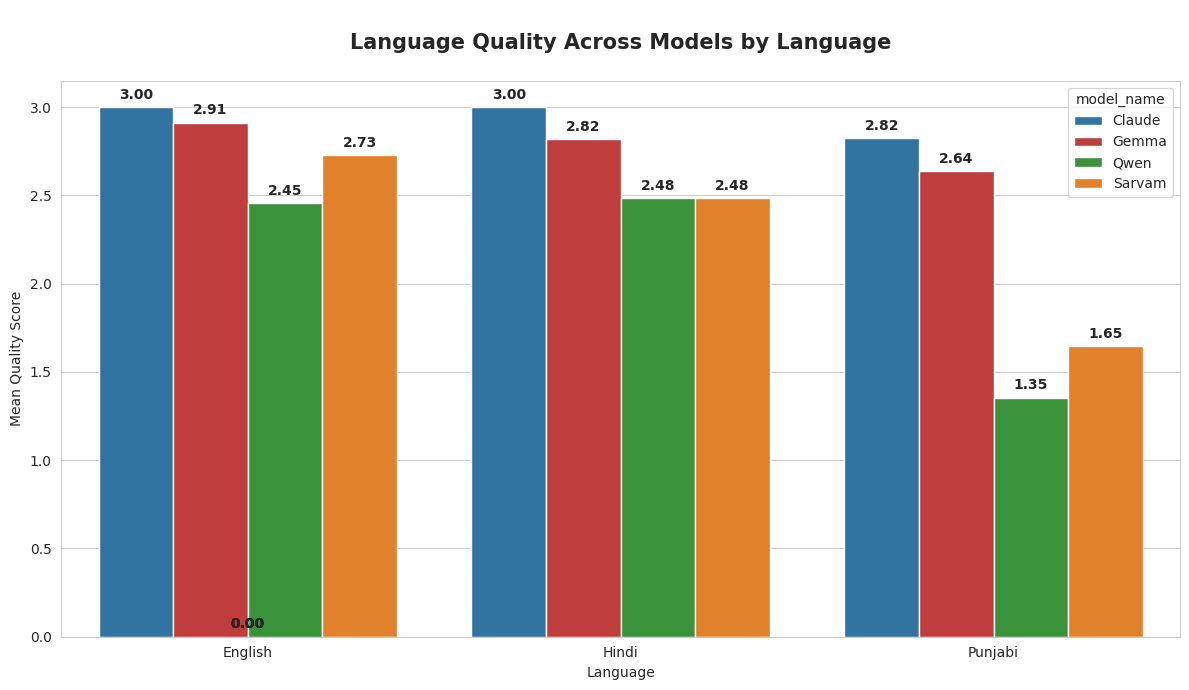

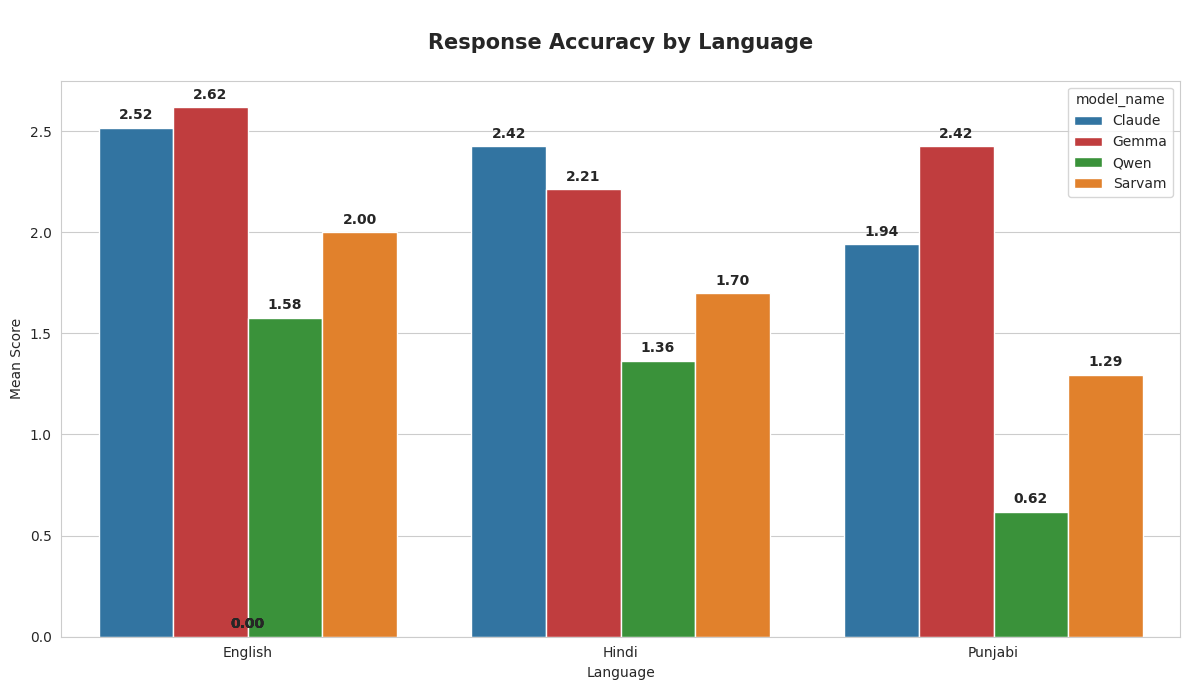

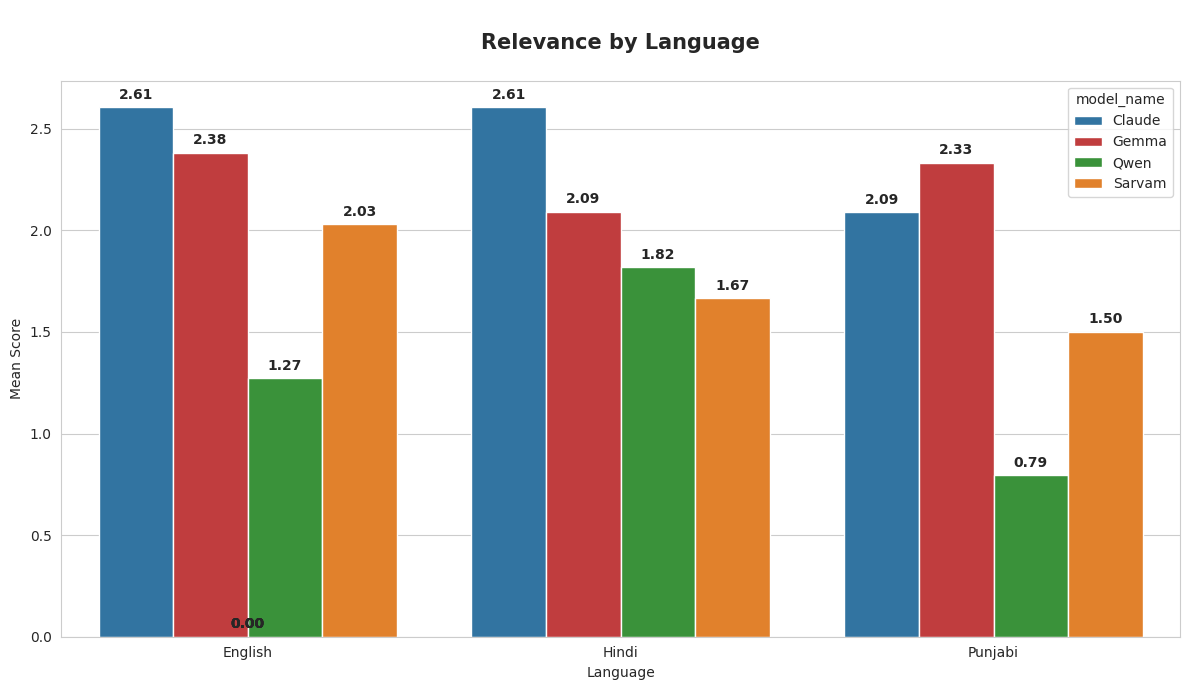

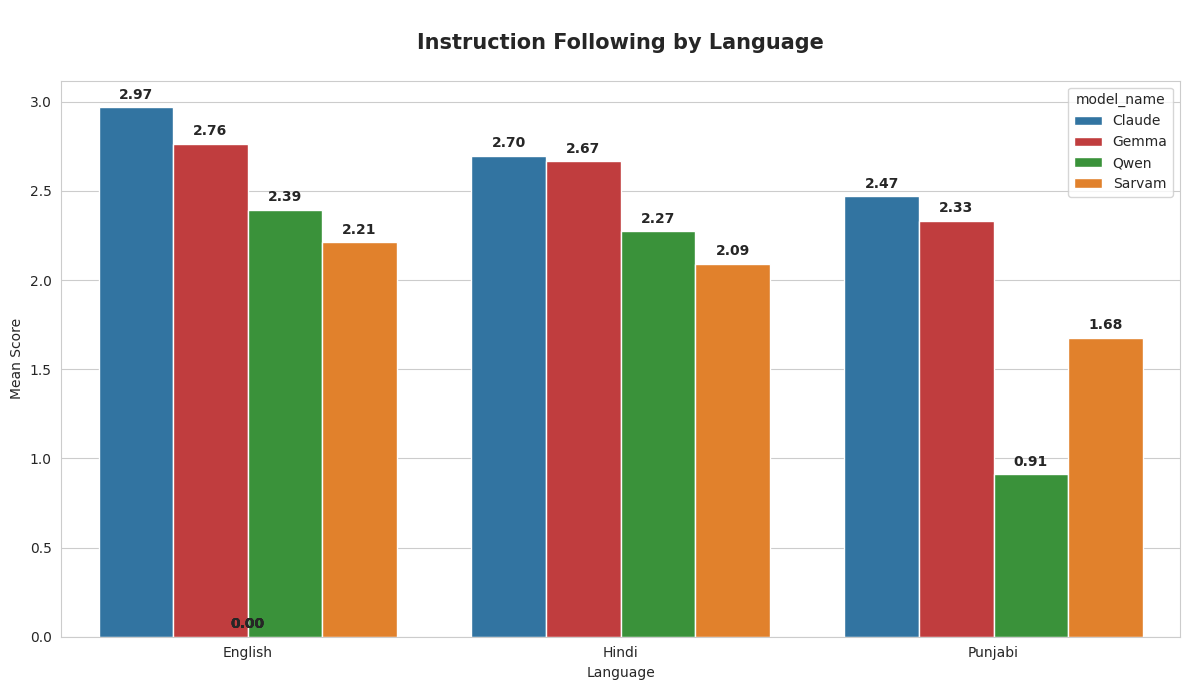

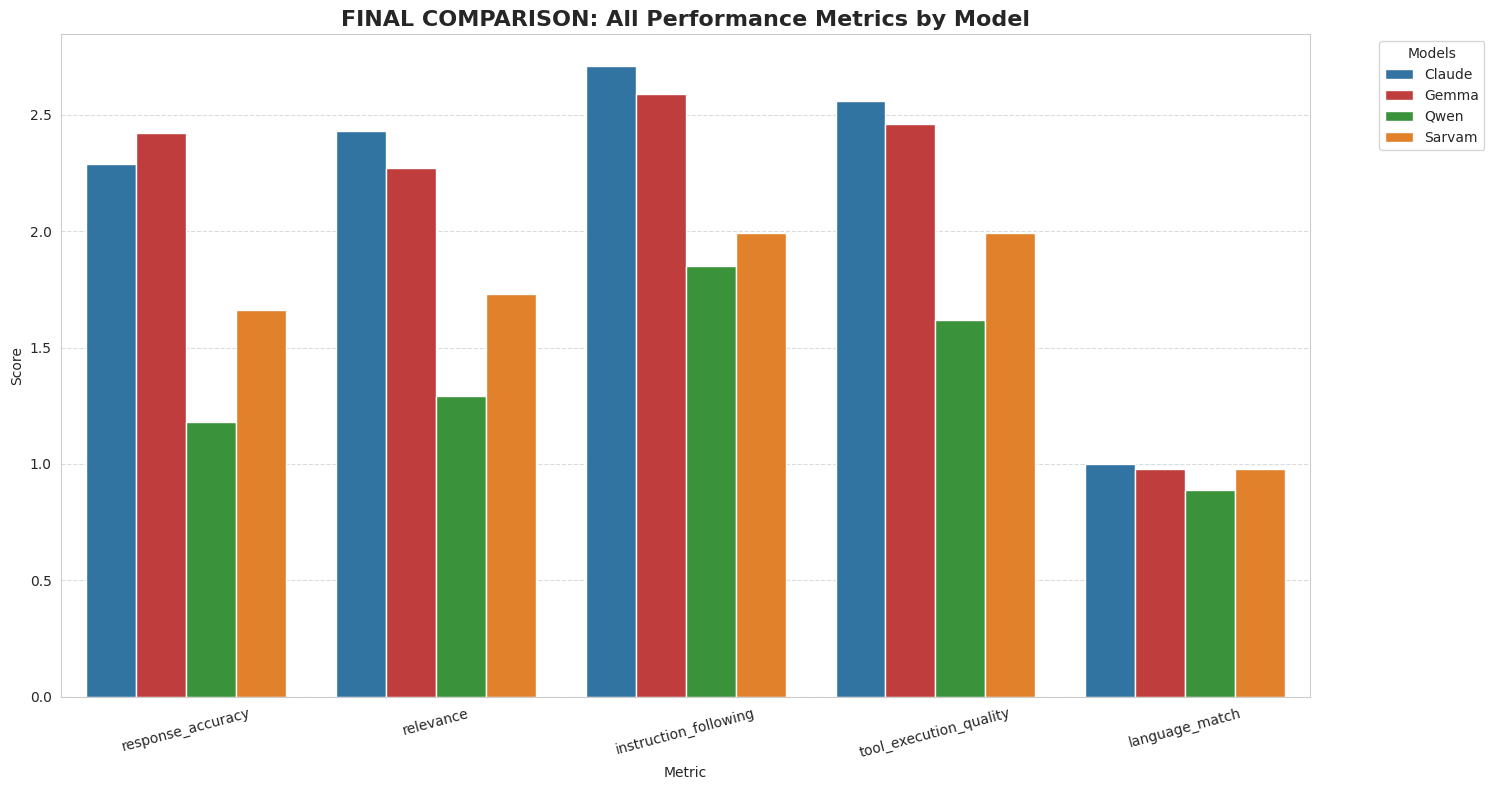


--- LANGUAGE MATCH RATE PER MODEL ---
  model_name  language_match
0     Claude            1.00
1      Gemma            0.98
3     Sarvam            0.98
2       Qwen            0.89

--- LANGUAGE QUALITY PIVOT TABLE ---
model_name    Claude     Gemma      Qwen    Sarvam
Language                                          
English     3.000000  2.911765  2.454545  2.727273
Hindi       3.000000  2.818182  2.484848  2.484848
Punjabi     2.823529  2.636364  1.352941  1.647059


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- CONFIGURATION ---
FILE_PATH = "100 Test Questions.xlsx"
MODEL_COLORS = {
    'Claude': '#1f77b4', # Blue
    'Qwen': '#2ca02c',   # Green
    'Gemma': '#d62728',  # Red
    'Sarvam': '#ff7f0e'  # Orange
}

class DataIngestion:
    @staticmethod
    def load_data(path):
        """Reads all sheets from Excel and returns a dict of DataFrames."""
        xls = pd.ExcelFile(path)
        # Dynamically read all sheets as specified in the prompt
        return {sheet: xls.parse(sheet) for sheet in xls.sheet_names if sheet in MODEL_COLORS.keys()}

class DataCleaner:
    @staticmethod
    def extract_numeric(value):
        """Extracts the first number found in a string (e.g., '3 (100% correct)' -> 3)."""
        if pd.isna(value): return np.nan
        nums = re.findall(r"[-+]?\d*\.\d+|\d+", str(value))
        return float(nums[0]) if nums else np.nan

    @classmethod
    def clean_pipeline(cls, df, model_name):
        df = df.copy()
        # 1. Strip column names
        df.columns = df.columns.str.strip()

        # 2. Extract numeric scores
        score_cols = ['response_accuracy', 'tool_execution_quality', 'instruction_following',
                      'language_quality', 'relevance', 'latency_sec']
        for col in score_cols:
            if col in df.columns:
                df[col] = df[col].apply(cls.extract_numeric)

        # 3. Binary Conversions
        binary_map = {'yes': 1, 'no': 0, 'na': 0}
        df['question understood'] = df['question understood'].astype(str).str.lower().str.strip().map(binary_map).fillna(0)
        df['Follow-up question required'] = df['Follow-up question required'].astype(str).str.lower().str.strip().map(binary_map).fillna(0)

        # 4. Normalize text
        text_cols = ['Language', 'Response lang', 'Crop', 'State', 'District']
        for col in text_cols:
            if col in df.columns:
                df[col] = df[col].astype(str).str.strip().str.capitalize()

        df['model_name'] = model_name
        return df

class FeatureEngineer:
    @staticmethod
    def add_features(df):
        # Language Match Check
        df['language_match'] = (df['Language'] == df['Response lang']).astype(int)
        return df

class Visualizer:
    def __init__(self, colors):
        self.colors = colors

    def plot_bar(self, data, x, y, title, ylabel, hue=None, is_comparison=False):
        plt.figure(figsize=(12, 7))
        sns.set_style("whitegrid")

        if is_comparison:
            ax = sns.barplot(data=data, x=x, y=y, palette=self.colors)
        else:
            ax = sns.barplot(data=data, x=x, y=y, hue=hue, palette=self.colors if hue else None)

        plt.title(f"\n{title}\n", fontsize=15, fontweight='bold')
        plt.ylabel(ylabel)
        plt.xlabel(x.replace('_', ' ').title())

        # Add value labels
        for p in ax.patches:
            ax.annotate(format(p.get_height(), '.2f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=10, fontweight='bold')

        plt.tight_layout()
        plt.show()

# --- MAIN EXECUTION PIPELINE ---

# 1. Ingestion
raw_data_dict = DataIngestion.load_data(FILE_PATH)
all_dfs = []

# 2. Cleaning & Engineering
for model, df in raw_data_dict.items():
    cleaned_df = DataCleaner.clean_pipeline(df, model)
    engineered_df = FeatureEngineer.add_features(cleaned_df)
    all_dfs.append(engineered_df)

master_df = pd.concat(all_dfs, ignore_index=True)

# 3. Dataset-Level Insights
print("--- DATASET INSIGHTS ---")
print(f"Total Records: {len(master_df)}")
print(f"Unique Questions: {master_df['Query text'].nunique()}")
print(f"Total Evaluators: {master_df['Agri Expert'].nunique()}")
print("-" * 25)

# 4. Metrics Computation
metrics_to_avg = ['response_accuracy', 'relevance', 'instruction_following',
                  'tool_execution_quality', 'latency_sec', 'language_match']

model_metrics = master_df.groupby('model_name')[metrics_to_avg].mean().reset_index()

# 5. Visualizations
viz = Visualizer(MODEL_COLORS)

# A. Individual Metric Comparisons
metrics_meta = [
    ('response_accuracy', 'Accuracy Comparison Across Models', 'Mean Accuracy Score'),
    ('relevance', 'Relevance Comparison Across Models', 'Mean Relevance Score'),
    ('instruction_following', 'Instruction Following Comparison', 'Mean Score'),
    ('tool_execution_quality', 'Tool Execution Quality Comparison', 'Mean Score'),
    ('latency_sec', 'Average Latency Comparison (Lower is Better)', 'Seconds'),
    ('language_match', 'Language Match Rate (Input vs Output)', 'Match Rate (0-1)')
]

for col, title, ylabel in metrics_meta:
    viz.plot_bar(model_metrics, 'model_name', col, title, ylabel, is_comparison=True)

# B. Language Quality Analysis
lang_quality = master_df.groupby(['Language', 'model_name'])['language_quality'].mean().reset_index()
viz.plot_bar(lang_quality, x='Language', y='language_quality', hue='model_name',
             title='Language Quality Across Models by Language', ylabel='Mean Quality Score')

# C. Model x Language Multi-Metric Performance
for metric in ['response_accuracy', 'relevance', 'instruction_following']:
    perf = master_df.groupby(['Language', 'model_name'])[metric].mean().reset_index()
    viz.plot_bar(perf, x='Language', y=metric, hue='model_name',
                 title=f'{metric.replace("_", " ").title()} by Language', ylabel='Mean Score')

# D. Final Concluding Graph (Melted for Multi-Metric View)
concluding_df = model_metrics.melt(id_vars='model_name', var_name='Metric', value_name='Score')
# Exclude latency from this specific graph as it's on a different scale
concluding_df = concluding_df[concluding_df['Metric'] != 'latency_sec']

plt.figure(figsize=(15, 8))
sns.barplot(data=concluding_df, x='Metric', y='Score', hue='model_name', palette=MODEL_COLORS)
plt.title("FINAL COMPARISON: All Performance Metrics by Model", fontsize=16, fontweight='bold')
plt.xticks(rotation=15)
plt.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 6. Detailed Output Tables for Stakeholders
print("\n--- LANGUAGE MATCH RATE PER MODEL ---")
print(model_metrics[['model_name', 'language_match']].sort_values(by='language_match', ascending=False))

print("\n--- LANGUAGE QUALITY PIVOT TABLE ---")
lang_pivot = master_df.pivot_table(index='Language', columns='model_name', values='language_quality', aggfunc='mean')
print(lang_pivot)


              DATASET LEVEL INSIGHTS
╒══════════════════════════╤══════════════════════════════════════╕
│ Total Evaluation Records │ 500                                  │
├──────────────────────────┼──────────────────────────────────────┤
│ Unique Query Texts       │ 102                                  │
├──────────────────────────┼──────────────────────────────────────┤
│ Total Agri Experts       │ 10                                   │
├──────────────────────────┼──────────────────────────────────────┤
│ Models Evaluated         │ Qwen-ft, Qwen, Claude, Gemma, Sarvam │
╘══════════════════════════╧══════════════════════════════════════╛

             MODEL PERFORMANCE SUMMARY
+--------------+---------------------+-------------+-------------------------+--------------------------+--------------------+---------------+------------------+
| model_name   |   response_accuracy |   relevance |   instruction_following |   tool_execution_quality |   language_quality |   latency_sec |   lan

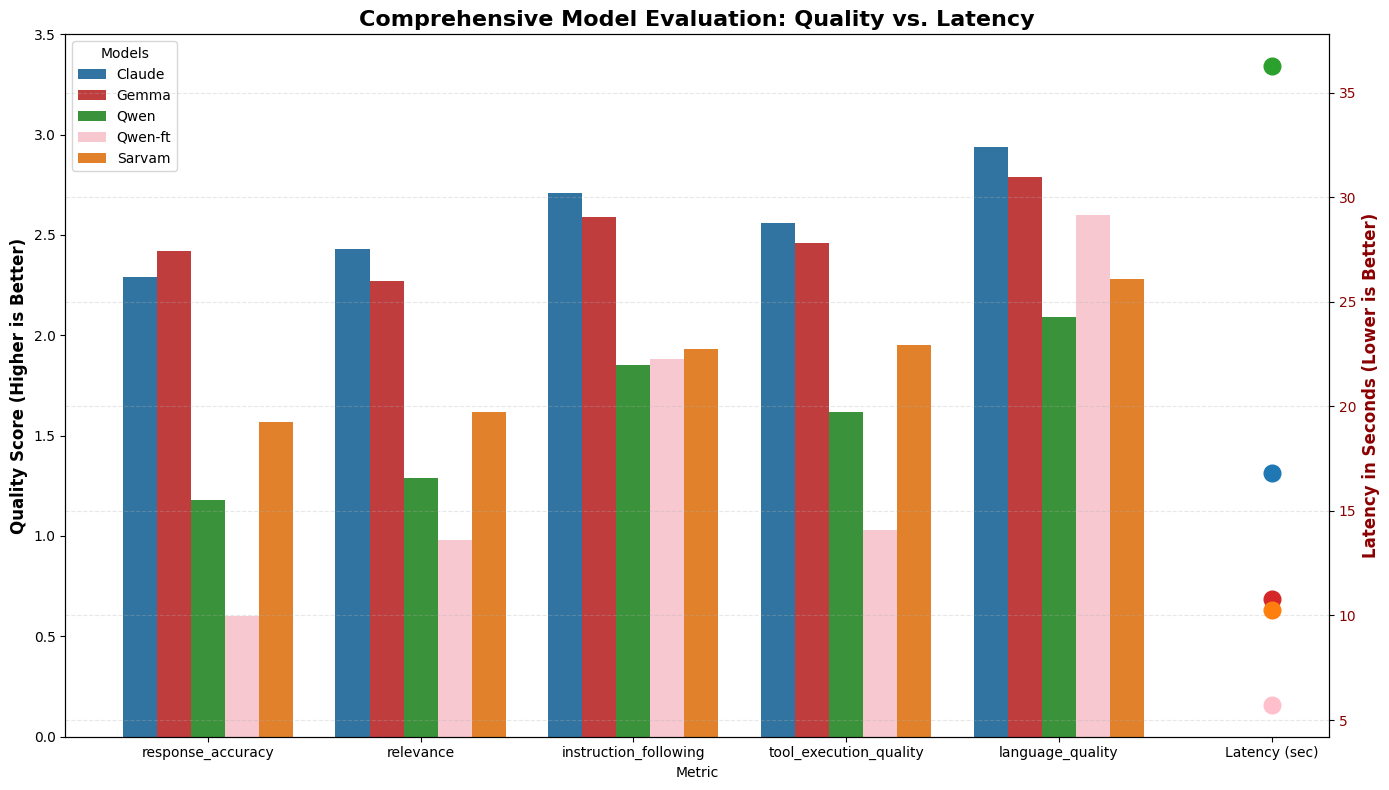

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tabulate import tabulate # Use 'pip install tabulate' if not present

# --- CONFIGURATION ---
FILE_PATH = "100 Test Questions .xlsx"
# Updated to classic distinct colors as requested
MODEL_COLORS = {
    'Claude': '#1f77b4', # Blue
    'Qwen': '#2ca02c',   # Green
    'Qwen-ft': '#FFC0CB', #Pink
    'Gemma': '#d62728',  # Red
    'Sarvam': '#ff7f0e'  # Orange
}

class DataCleaner:
    @staticmethod
    def extract_numeric(value):
        """Extracts the first number found in a string (e.g., '3 (100% correct)' -> 3)."""
        if pd.isna(value): return np.nan
        nums = re.findall(r"[-+]?\d*\.\d+|\d+", str(value))
        return float(nums[0]) if nums else np.nan

    @classmethod
    def clean_pipeline(cls, df, model_name):
        df = df.copy()
        df.columns = df.columns.str.strip()

        score_cols = ['response_accuracy', 'tool_execution_quality', 'instruction_following',
                      'language_quality', 'relevance', 'latency_sec']

        for col in score_cols:
            if col in df.columns:
                df[col] = df[col].apply(cls.extract_numeric)

        binary_map = {'yes': 1, 'no': 0, 'na': 0}

        # Safely process 'question understood' if it exists
        if 'question understood' in df.columns:
            df['question understood'] = df['question understood'].astype(str).str.lower().str.strip().map(binary_map).fillna(0)
        else:
            df['question understood'] = 0 # Default to 0 if column is missing

        # Safely process 'Follow-up question required' if it exists
        if 'Follow-up question required' in df.columns:
            df['Follow-up question required'] = df['Follow-up question required'].astype(str).str.lower().str.strip().map(binary_map).fillna(0)
        else:
            df['Follow-up question required'] = 0 # Default to 0 if column is missing

        # Safely process 'Language' if it exists
        if 'Language' in df.columns:
            df['Language'] = df['Language'].astype(str).str.strip().str.capitalize()
        else:
            df['Language'] = 'Unknown' # Default to 'Unknown' if column is missing

        # Safely process 'Response lang' if it exists
        if 'Response lang' in df.columns:
            df['Response lang'] = df['Response lang'].astype(str).str.strip().str.capitalize()
        else:
            df['Response lang'] = 'Unknown' # Default to 'Unknown' if column is missing

        df['model_name'] = model_name
        df['language_match'] = (df['Language'] == df['Response lang']).astype(int)

        return df

# --- PROCESSING ---
xls = pd.ExcelFile(FILE_PATH)
all_dfs = [DataCleaner.clean_pipeline(xls.parse(sheet), sheet) for sheet in xls.sheet_names if sheet in MODEL_COLORS.keys()]
master_df = pd.concat(all_dfs, ignore_index=True)

# --- METRICS CALCULATION ---
metrics_cols = ['response_accuracy', 'relevance', 'instruction_following', 'tool_execution_quality', 'language_quality', 'latency_sec', 'language_match']
model_summary = master_df.groupby('model_name')[metrics_cols].mean().reset_index()

# --- PRINTING INSIGHTS (Proper Format) ---
print("\n" + "="*50)
print("              DATASET LEVEL INSIGHTS")
print("="*50)
insights = [
    ["Total Evaluation Records", len(master_df)],
    ["Unique Query Texts", master_df['Query text'].nunique()],
    ["Total Agri Experts", master_df['Agri Expert'].nunique()],
    ["Models Evaluated", ", ".join(master_df['model_name'].unique())]
]
print(tabulate(insights, tablefmt="fancy_grid"))

print("\n" + "="*50)
print("             MODEL PERFORMANCE SUMMARY")
print("="*50)
# Round for cleaner display
display_summary = model_summary.round(2)
print(tabulate(display_summary, headers='keys', tablefmt="psql", showindex=False))

# --- FINAL CONCLUDING GRAPH (Dual Axis) ---
def plot_concluding_chart(df):
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Melt for grouped bars (excluding Latency for primary axis)
    melted = df.melt(id_vars='model_name',
                     value_vars=['response_accuracy', 'relevance', 'instruction_following', 'tool_execution_quality', 'language_quality'],
                     var_name='Metric', value_name='Score')

    sns.barplot(data=melted, x='Metric', y='Score', hue='model_name', palette=MODEL_COLORS, ax=ax1)

    ax1.set_title('Comprehensive Model Evaluation: Quality vs. Latency', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Quality Score (Higher is Better)', fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 3.5) # Assuming a 3-point scale
    ax1.legend(title='Models', loc='upper left')

    # Create secondary axis for Latency
    ax2 = ax1.twinx()
    # Plot latency as a line or points to distinguish it from the bars
    for model in df['model_name']:
        model_data = df[df['model_name'] == model]
        ax2.plot(['Latency (sec)'], model_data['latency_sec'], marker='o', markersize=12,
                 color=MODEL_COLORS[model], label=f'{model} Latency', linewidth=0)

    ax2.set_ylabel('Latency in Seconds (Lower is Better)', color='darkred', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='darkred')

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_concluding_chart(model_summary)

In [ ]:
master_df

,Agri Expert,Query text,Follow-up question required,Crop,State,District,Season,Domain,Query type,Language,...,response_accuracy,tool_execution_quality,instruction_following,language_quality,relevance,latency_sec,comments,model_name,language_match,Unnamed: 20
0,Monica M,How to manage dila motha weed in water standin...,0.0,Paddy,Punjab,Gurdaspur,Kharif,Weed Management,Crop-related,English,...,0.0,0.0,0.0,3.0,0.0,4.0,"Answer is not generated and shows as,query wil...",Qwen-ft,1,NaN
1,Monica M,What is the recommended fertilizer dose?\n\n,0.0,Paddy,Punjab,Amritsar\n,Kharif,Nutrient Management,Crop-related,English,...,0.0,2.0,3.0,3.0,0.0,9.0,The given fertilizer dose is wrong and source ...,Qwen-ft,1,NaN
2,Monica M,What are the key field management practices fo...,0.0,Paddy,Punjab,BHATINDA\n,Kharif,Nutrient Management\n,Crop-related,English,...,1.0,3.0,3.0,3.0,0.0,4.0,The given source link is not working and prope...,Qwen-ft,1,NaN
3,Monica M,How can I contact the Chief Agriculture Office...,0.0,Paddy,Punjab,BHATINDA\n,Kharif,Cultural Practices\n,Crop-related,English,...,0.0,3.0,3.0,3.0,0.0,4.0,"The provided answer is not corrcet , source li...",Qwen-ft,1,NaN
4,Monica M,How do you prepare Pusa Decomposer solution fo...,0.0,Paddy,Punjab,MUKTSAR\n,Kharif,Field Preparation\n,Crop-related,English,...,0.0,0.0,1.0,3.0,0.0,5.0,Answer is not generated source link in not wor...,Qwen-ft,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Simranpreet Kaur,ਇਮਾਮੈਕਟਿਨ ਬੈਂਜੋਏਟ 5% + ਪ੍ਰੋਫੇਨੋਫੋਸ 40% ਡਬਲਯੂ....,0.0,Paddy,Haryana,FAQ,Kharif,Pest,Crop-related,Punjabi,...,0.0,0.0,0.0,0.0,0.0,5.0,source not generated and also the question was...,Sarvam,1,NaN
496,Simranpreet Kaur,ਝੋਨੇ ਦੀਆਂ ਕਿਸਮਾਂ ਪੀਬੀ 1847 ਅਤੇ ਪੀਬੀ 1692 ਦੀ ਪਰ...,0.0,Paddy,Haryana,FAQ,Kharif,Variety,Crop-related,Punjabi,...,0.0,3.0,1.0,0.0,0.0,8.0,answer generated but without source,Sarvam,1,NaN
497,Simranpreet Kaur,ਝੋਨੇ ਵਿੱਚ ਦਾਣੇ ਦੇ ਰੰਗ ਨੂੰ ਕਿਵੇਂ ਕੰਟਰੋਲ ਕਰੀਏ?,0.0,Paddy,Haryana,FAQ,Kharif,Disease,Crop-related,Punjabi,...,0.0,3.0,1.0,0.0,0.0,5.0,answer generated but without source,Sarvam,1,NaN
498,Simranpreet Kaur,ਕੀ ਮੈਂ ਝੋਨੇ ਦੀ ਫ਼ਸਲ 'ਤੇ ਤੇਲੇ (aphids) ਲਈ ਸਪਰੇਅ...,0.0,Paddy,Punjab,SANGRUR,Kharif,Plant Protection,Crop-related,Punjabi,...,0.0,2.0,1.0,0.0,0.0,5.0,source attached were wrong and also some param...,Sarvam,1,NaN


### Inspecting the 'Qwen-ft' Sheet Structure

The `NameError: name 'master_df' is not defined` from the previous execution of cell `3c53b381` was due to the syntax error in cell `GwsPA36vpJhq` not allowing `master_df` to be created. That has now been fixed, and `master_df` is correctly populated.

However, the performance summary for 'Qwen-ft' still shows `NaN` values for most metrics. This is because the raw column names in the 'Qwen-ft' sheet are not matching the expected metric names. Let's load just the 'Qwen-ft' sheet and display its head to understand its structure and identify what the 'Unnamed' columns represent.

In [ ]:
xls = pd.ExcelFile(FILE_PATH)
qwen_ft_df_raw = xls.parse('Qwen-ft')
display(qwen_ft_df_raw.head())

,https://chat.vicharanashala.ai/c/new?spec=ajrasakha-qwen-ft-ffv,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,Agri Expert,Query text,Follow-up question required,Crop,State,District,Season,Domain,Query type,Language,question uploaded,question understood,Response lang,response_accuracy,tool_execution_quality,instruction_following,language_quality,relevance,latency_sec,comments
1,Monica M,How to manage dila motha weed in water standin...,NaN,Paddy,Punjab,Gurdaspur,Kharif,Weed Management,Crop-related,English,"""Yes, with correct parameters""",Yes,English,0,0,0,3 (100% correct),0,4secs,"Answer is not generated and shows as,query wil..."
2,Monica M,What is the recommended fertilizer dose?\n\n,for Paddy cultivation in Punjab?,Paddy,Punjab,Amritsar\n,Kharif,Nutrient Management,Crop-related,English,"""Yes, with correct parameters""",Yes,English,0,2 (90% correct),3 (100% correct),3 (100% correct),0,9 secs,The given fertilizer dose is wrong and source ...
3,Monica M,What are the key field management practices fo...,NaN,Paddy,Punjab,BHATINDA\n,Kharif,Nutrient Management\n,Crop-related,English,"""Yes, with correct parameters""",Yes,English,1 (50% correct),3 (100% correct),3 (100% correct),3 (100% correct),0,4 secs,The given source link is not working and prope...
4,Monica M,How can I contact the Chief Agriculture Office...,of Bathinda district in Punjab?,Paddy,Punjab,BHATINDA\n,Kharif,Cultural Practices\n,Crop-related,English,"""Yes, with correct parameters""",Yes,English,0,3 (100% correct),3 (100% correct),3 (100% correct),0,4 secs,"The provided answer is not corrcet , source li..."
